In [30]:
# importing the libraries

import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn packages
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

# import warnings
import warnings
warnings.filterwarnings('ignore')

In [31]:
# import the data
df= pd.read_csv('/content/drive/MyDrive/Copy of sms_spam.csv')

In [32]:
df.head()

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [33]:
df.loc[3,'text']

'U dun say so early hor... U c already then say...'

In [34]:
df.shape

(5574, 2)

In [35]:
df.isnull().sum()

,0
type,0
text,0


In [36]:
df.dtypes

,0
type,object
text,object


In [37]:
# distribution of the column
round(df['type'].value_counts(normalize=True)*100,2)

,proportion
type,
ham,86.6
spam,13.4


There is class imbalance and this leads to low/poor recall score if not balanced

In [38]:
df.groupby('type').describe()

text                                                               
     count unique                                                top freq
type                                                                     
ham   4827   4518                             Sorry, I'll call later   30
spam   747    642  Please call our customer service representativ...    4

In [39]:
df['length'] = df['text'].apply(len)

In [40]:
df.head()

,type,text,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


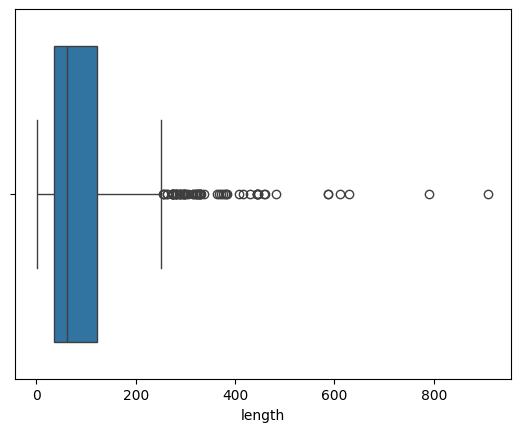

In [41]:
sns.boxplot(df['length'], orient='h')
plt.show()

In [42]:
df['length'].describe()

,length
count,5574.000000
mean,80.444923
std,59.841828
min,2.000000
25%,36.000000
50%,61.000000
75%,122.000000
max,910.000000


In [43]:
# min length message

df[df['length'] == df['length'].min()]['text'].value_counts()

,count
text,
Ok,4
:),1


In [44]:
df[df['length'] == df['length'].max()]['text'].iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

CountVectorizer (BOW : vocabulary) >> TfidfTransformer (TF-IDF Values)

Instead use TfidfVectorizer to apply both steps together

In [45]:
# train_test_split

x_train,x_test,y_train,y_test= train_test_split(df['text'], df['type'], random_state=42, test_size=0.2)

# vectorizer
vectorizer= TfidfVectorizer(stop_words='english')
x_train_tfidf = vectorizer.fit_transform(x_train)        # training vocalbulary and train transformed vector

x_test_tfidf = vectorizer.transform(x_test)         # training vocalbulary and test transformed vector

In [46]:
x_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34695 stored elements and shape (4459, 7463)>

In [47]:
# classification model

model= MultinomialNB()
model.fit(x_train_tfidf,y_train)
train_score = round(model.score(x_train_tfidf, y_train)*100, 2)

In [48]:
# model_prediction
y_pred= model.predict(x_test_tfidf)

In [49]:
# model accuracy prediction

print('Training score : ', train_score,'%')
print('Testing score : ', round(accuracy_score(y_test,y_pred)*100,2), '%')

Training score :  98.23 %
Testing score :  97.4 %


Classification Report:

               precision    recall  f1-score   support

         ham       0.97      1.00      0.99       954
        spam       1.00      0.82      0.90       161

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



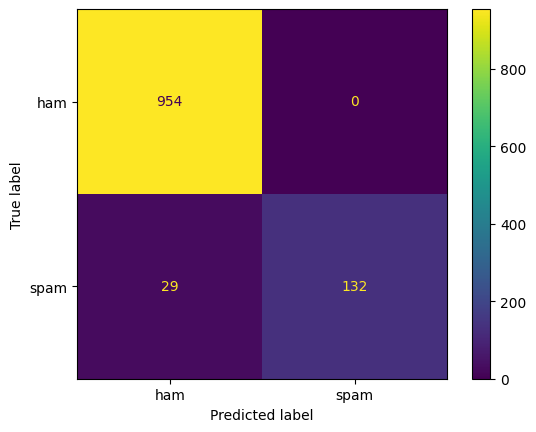

In [50]:
# metric validation
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('Classification Report:\n\n', classification_report(y_test, y_pred))

In [51]:
# function to predict a new incoming message as spam/ ham
def predict_message():
    message = str(input('Enter a message to classify spam/ ham: '))
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)
    return 'The message is Ham.' if prediction[0] == "ham" else 'The message is Spam.'

In [52]:
predict_message()

Enter a message to classify spam/ ham: Hi how are you


'The message is Ham.'

In [53]:
predict_message()


Enter a message to classify spam/ ham: I will visit office tomo and we will catch up to discuss about the new business proposal


'The message is Ham.'

In [54]:
predict_message()

Enter a message to classify spam/ ham: Please visit our showroom to claim your reward


'The message is Spam.'

In [55]:
predict_message()

Enter a message to classify spam/ ham:  You got a prize amount. Call our cusotmer service to claim it today


'The message is Spam.'